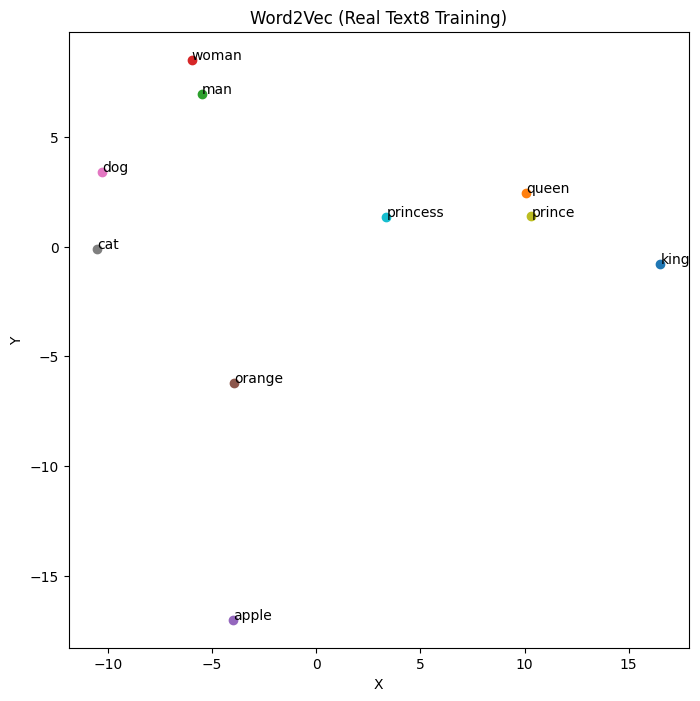

In [19]:
import gensim.downloader as api
from gensim.models import Word2Vec

with open("/mnt/disk4/hongzk/text8.txt", "r") as f:
    text = f.read().split()

sentences = []
for i in range(0, len(text), 100):   # 每100个词作为一句
    sentences.append(text[i:i+100])

# ⚠️ 只用一部分（加速）
sentences = sentences[:10000000]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=10,
    min_count=1,
    workers=4
)

# 选词（可以换）
words =  [
    "king", "queen",     
    "man", "woman",        
    "apple", "orange",    
    "dog", "cat",          
    "prince", "princess"   
]

words = [w for w in words if w in model.wv]

vectors = [model.wv[w] for w in words]

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X = pca.fit_transform(vectors)

plt.figure(figsize=(8, 8))
for i, word in enumerate(words):
    plt.scatter(X[i, 0], X[i, 1])
    plt.text(X[i, 0] + 0.01, X[i, 1] + 0.01, word)

plt.title("Word2Vec (Real Text8 Training)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()